# eBay Laptops & Notebooks - Data Cleansing

The following dataset contains information about laptops and notebooks, by web scraping the popular e-commerce website
**eBay**.

The dataset contains information about the laptop prices (possible variable of interest), brand, ratings, condition, as well as hardware information (processor, screen size, ram, etc).

<div style="text-align: center;">
<img src="../assets/logos/ebay.png" width="250"/>
</div>

In [1]:
# Importing libraries and setting constants
import polars as pl
from polars import LazyFrame
import re

# Data source location
DATA_SOURCE_PATH = '../data/ebay_laptops_and_notebooks.csv'

## Data Exploration

In [2]:
# Loading the dataset
df = pl.read_csv(DATA_SOURCE_PATH)

# Top 10 rows from the dataframe
df.head(n=10)

Brand,Price,Rating,Ratings Count,Condition,Seller Note,Processor,Screen Size,Manufacturer Color,Color,Ram Size,SSD Capacity,GPU,Processor Speed,Type,Release Year,Maximum Resolution,Model,OS,Features,Hard Drive Capacity,Country Region Of Manufacturer,Storage Type
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""CHUWI""","""$303.68 """,null,null,"""New: A brand-new, unused, unop…",null,"""Quad Core""","""14 in""",null,"""Gray""","""8 GB""","""1 Used, 1 support Max 1TB M.2…","""Intel Iris Plus Graphics 655""","""Max up to 3.80 GHz""","""Notebook/Laptop""","""2021""","""2160 x 1440""","""CoreBook X""","""Windows 11 Home""","""Backlit Keyboard, Built-in Mi…","""512 GB SSD""","""China""","""SSD (Solid State Drive)"""
"""Dell""","""$399.99 to $634.99""",null,null,"""Very Good - RefurbishedThe ite…","""“AAA PCs is a Microsoft Author…","""Intel Core i7 8th Gen.""","""14 in""",null,"""Black""",null,null,"""Intel UHD Graphics 620""","""4.20 GHz (1.90 GHz Base Freque…","""Notebook/Laptop""","""Refurbished in 2023""","""1920 x 1080""","""Dell Latitude 7490""","""Windows 11 Pro""","""Backlit Keyboard, Bluetooth, B…","""2 TB""",null,"""SSD (Solid State Drive)"""
"""Dell""","""$175.00 """,null,null,"""UsedAn item that has been used…","""“Well kept, fully functional, …","""Intel Core i5-6300U""","""14 in""",null,"""Black""","""16 GB""","""500 GB""","""Intel HD Graphics""","""2.40 GHz""","""Notebook/Laptop""","""2019""","""1920 x 1080""","""Dell Latitude E5470""","""Windows 10 Pro""","""10/100 LAN Card, Backlit Keybo…","""500 GB""","""China""","""SSD (Solid State Drive)"""
"""HP""","""$84.99 """,null,null,"""Good - RefurbishedThe item sho…","""“1-Year Allstate warranty. The…","""Intel Celeron N""","""11.6 in""",null,"""Black""","""4 GB""",null,"""Intel HD Graphics 500""","""2.40 GHz""","""Notebook/Laptop""",null,"""1366 x 768""","""HP Chromebook 11 G6""","""Chrome OS""","""Bluetooth, Built-in Microphone…","""16 GB""",null,"""eMMC"""
"""Dell""","""$101.22 """,null,null,"""Good - RefurbishedThe item sho…","""“Laptops is tested & fully wor…","""Intel Core i5 6th Gen.""","""Minimum 12.5""""",null,null,"""8 GB""","""256 GB""","""Integrated""","""Minimum 1.40 GHz""","""Notebook/Laptop""","""2015""","""1366 x 768""","""Various Models""","""Windows 10""","""10/100 LAN Card, Built-in Micr…","""NO HDD""",null,"""SSD (Solid State Drive)"""
"""Acer""","""$49.99 ""","""4.5 out of 5 stars""",193,null,null,"""Intel Celeron""","""11.6 in""","""Black""","""Black""","""4 GB""","""16 GB""",null,"""1.60 GHz""","""Laptop""","""2017""","""1366 x 768""","""Chromebook C738T-C44Z""","""Chrome OS""","""Touchscreen, Bluetooth""",null,null,"""SSD (Solid State Drive)"""
"""HP""","""$39.59 ""","""4.5 out of 5 stars""",23,null,null,"""Intel Celeron""","""11.6 in""",null,"""Black""","""4 GB""","""16GB""",null,"""1.60 GHz""","""Notebook/Laptop""","""2017""",null,"""HP Chromebook 11 G5""","""Chrome OS""","""Bluetooth, Built-in Webcam""","""16 GB""",null,"""SSD (Solid State Drive)"""
"""Acer""","""$34.99 ""","""5 out of 5 stars""",20,null,null,"""Intel Celeron Dual-Core""","""11.6 inin""",null,"""Gray, Granite Gray""","""2GB""",null,null,"""1.00 GHz.4ghz""","""Netbook""",null,null,"""Chromebook C720-2848""","""Chrome OS""",null,"""16GB""",null,null
"""Dell""","""$279.99 """,null,null,"""Excellent - Refurbished: The i…",null,"""i7 7th""","""14 in""",null,"""Black""","""16 GB""","""500 GB""",null,"""2.80 GHz""","""Notebook/Laptop""",null,"""1920 x 1080""","""Dell Latitude 7480""","""win 11 pro""","""Wi-Fi""","""512 GB""",null,"""SSD (Solid State Drive)"""


Observations:

* `Price` variable contains information about the price itself, but also the currency. Also, some prices are in a range format, such as `$399.99 to $634.99` which needs to be handled before converting `Price` into a numerical variable.
* **Several** columns are being treated as `String` (such as `Price`), which might not be adequate.
* **Several** columns have **missing values**, which needs to be treated during further data preprocessing.

### Summary Statistics

We compute the summary statistics for our dataset, but we instantly notice most of our columns are nullable, which makes statistics, such as the mean and standard deviation, to output `null` too.

In [3]:
# Summary statistics
df.describe()

statistic,Brand,Price,Rating,Ratings Count,Condition,Seller Note,Processor,Screen Size,Manufacturer Color,Color,Ram Size,SSD Capacity,GPU,Processor Speed,Type,Release Year,Maximum Resolution,Model,OS,Features,Hard Drive Capacity,Country Region Of Manufacturer,Storage Type
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""","""4024""","""6620""","""286""",286.0,"""6004""","""1442""","""3837""","""3890""","""185""","""2149""","""2112""","""2780""","""3088""","""2669""","""3289""","""787""","""2480""","""3148""","""3040""","""2505""","""2332""","""203""","""2388"""
"""null_count""","""2596""","""0""","""6334""",6334.0,"""616""","""5178""","""2783""","""2730""","""6435""","""4471""","""4508""","""3840""","""3532""","""3951""","""3331""","""5833""","""4140""","""3472""","""3580""","""4115""","""4288""","""6417""","""4232"""
"""mean""",null,null,null,42.479021,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",null,null,null,201.257428,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""","""?""","""$1,002.67 ""","""1 out of 5 stars""",1.0,"""Certified - Refurbished: The i…","""“""Excellent Condition Touch Sc…","""10th Gen Intel Core i5""","""10 in""","""3000""","""Abyss Blue""","""1 GB""",""".""",""".""","""1.00 GHz""","""2 IN 1 CHROMEBOOK""","""0""","""1024 x 480""","""100e Chromebook""","""ANDROID""",""".""",""".""","""Australia""","""."""
"""25%""",null,null,null,2.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",null,null,null,4.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",null,null,null,20.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""","""xnote""","""$999.95 ""","""5 out of 5 stars""",1533.0,"""Very Good - RefurbishedThe ite…","""“✅ Refurbished ✅ inkl. 19% MwS…","""unknown""","""none""","""onyx black""","""see pictures""","""up to 32GBGB DDR4""","""up to 1TB SSD""","""‎PowerVR GX6250""","""up to 3.6Ghz""","""Écran numériseur""","""see manufacturer""","""See Title/Description""","""xnote""","""‎Windows 11 Home""","""dvd""","""up to 1 TB""","""Unknown""","""ssd"""


### Null Count and Null Proportion

Now, we take a look at the `null count` and `null proportion` per each dataframe column:

In [4]:
# Nulls per each column in the dataset
df.null_count().unpivot(
    variable_name='variable',
    value_name='null_count',
).sort(
    by='null_count', descending=True,
).with_columns(
    (pl.col('null_count') / df.height).round(2).alias('null_proportion'),
)

variable,null_count,null_proportion
str,u32,f64
"""Manufacturer Color""",6435,0.97
"""Country Region Of Manufacturer""",6417,0.97
"""Rating""",6334,0.96
"""Ratings Count""",6334,0.96
"""Release Year""",5833,0.88
…,…,…
"""Processor""",2783,0.42
"""Screen Size""",2730,0.41
"""Brand""",2596,0.39


Observations:

- Extremely high percentage (85%+) of nulls for columns such as `country_region_of_manufacturer`, `ratings_count` or `release_year`.
- `Price` column has no null values.

### Data Types

We look at each column data type in the data frame

In [5]:
# Data Types
pl.DataFrame(data={
    'column': df.columns,
    'dtype': df.dtypes
})

column,dtype
str,object
"""Brand""",String
"""Price""",String
"""Rating""",String
"""Ratings Count""",Int64
"""Condition""",String
…,…
"""OS""",String
"""Features""",String
"""Hard Drive Capacity""",String


As aforementioned, some variables which are currently being treated as `String`, such as `Price`, are actually numerical. It's very important to find out whether this is a single column, or there are more occurrences within the dataframe.

## Data Preparation

## Column Renaming

We kick things off by *reformatting* the column names: lowercasing and removing spaces for underscores. These convention for string data will be **STANDARD** during our data cleansing process, so that most categorical data is transformed into similar formatting.

In [6]:
# Renaming columns: replacing blank spaces for underscores and lowercasing columns
df = df.rename({col: col.strip().lower().replace(' ', '_') for col in df.columns})
print(df.columns)

['brand', 'price', 'rating', 'ratings_count', 'condition', 'seller_note', 'processor', 'screen_size', 'manufacturer_color', 'color', 'ram_size', 'ssd_capacity', 'gpu', 'processor_speed', 'type', 'release_year', 'maximum_resolution', 'model', 'os', 'features', 'hard_drive_capacity', 'country_region_of_manufacturer', 'storage_type']


## Cleaning `brand`
- **Top categories**: The top three brands—Dell (19%), Lenovo (11%), and HP (7%)—represent a combined 37% of the total brands in the dataset. The null values account for 39% of the data, with 2596 entries marked as null. This is quite a large portion of the dataset. The top 4 categories (`null`, `Dell`, `Lenovo` & `HP`) account for 76% of the dataset.
- **Unknown values**: There's an abundance of brands with very low frequencies, or unknown values (like `?` or `Does not apply`).
- **Inconsistent formatting**: Some entries like `Dell Inc` are not captured under the main brand `Dell` due to inconsistent formatting. Similar things occur to other top brands.
- **Multibrand categories**: Some entries represent several brands, like `Dell / HP / Lenovo` or `Apple / LG`

In [7]:
# Taking a look at the frequency of each brand: total count and proportion
df['brand'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

brand,count,proportion
str,u32,f64
null,2596,0.39
"""Dell""",1273,0.19
"""Lenovo""",715,0.11
"""HP""",494,0.07
"""Acer""",147,0.02
…,…,…
"""Frontier""",1,0.0
"""Dell/HP/Lenovo/Stone""",1,0.0
"""SCSI""",1,0.0


### **Reformatting `brand`:**

In this step of our analysis, we're focusing on cleaning up and standardizing the `brand` data to ensure consistency and accuracy. Brands can be listed in many different ways, which can lead to confusion or misinterpretation during analysis. So, we're transforming the brand names into a uniform format that makes it easier to work with.

- **Consistent Formatting:** We ensure all brand names are in lowercase, and we remove any unnecessary spaces or punctuation that could create inconsistencies. (transforming `Dell Inc` into `dell_inc`).
- **Replacing Uncertain Values:** We also handle special cases where the data might have uncertain or irrelevant values (e.g., a "?" for unknown brands), replacing them with more meaningful terms like "unbranded" or "unknown."


In [8]:
# Define a mapping to replace certain placeholder values with more meaningful labels.
brand_replace_map = {
    '?': 'unbranded',  # Replace '?' with 'unbranded' for unknown brands.
    'does_not_apply': 'not_applicable',  # Replace 'does_not_apply' with 'not_applicable' to handle irrelevant data.
}

# Clean and normalize the brand names.
df = df.with_columns(
    pl.col('brand')
    .str.to_lowercase()  # Convert brand names to lowercase to ensure uniformity.
    .str.strip_chars()  # Remove any leading whitespace or special characters.
    .str.strip_chars_end('.')  # Specifically remove any trailing dots at the end of brand names.
    .str.replace_all(' / |\\/', ' or ')  # Replace slashes ("/" or " / ") with ' or ' to standardize multi-brand names.
    .str.replace_all(' ', '_')  # Replace spaces with underscores to ensure no spaces in brand names.
    .replace(brand_replace_map)  # Replace values like '?' or 'does_not_apply' based on the predefined map.
    .fill_null('unknown')  # Fill any missing brand values with 'unknown' to handle missing data.
    .alias('brand_clean')
)

### **Identifying and Mapping Top Brands:**

In this step, we're focusing on identifying the most popular brands in the dataset and ensuring that any variations in the brand names are mapped to the correct top brand.

- **Identifying Top Brands:** We start by filtering out any unknown brand names and then count the occurrences of each brand. From this, we identify the top 5 brands with the highest frequency in the dataset.
- **Pattern Matching:** We create a pattern to search for these top brands in the brand names. If the brand name matches one of the top brands (e.g., includes "dell", "hp", etc.), we recognize it as a valid entry for that brand.
- **Mapping Variations to Top Brands:** We then apply a function to map variations of the brand names (e.g., "dell_epsilon" or "hp_dell") to the main brand names (e.g., "dell" or "hp"). This ensures that similar or ambiguous entries are standardized to the correct top brand.

By applying these steps, we ensure that any variations or inconsistencies in the brand names are correctly mapped to the top brands, improving the consistency and accuracy of our analysis.


In [9]:
# Identify the top 5 most frequent brands in the dataset.
top_brands = (
    df.filter(pl.col('brand_clean').ne('unknown'))
    .group_by('brand_clean')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(5)
    .select('brand_clean')
    .to_series()
)

# Create a regex pattern to match brand names followed by an underscore (_).
is_a_top_brand_string_pattern = "|".join(re.escape(color) for color in top_brands + '_')


# Function to extract the actual brand from a string.
def return_actual_brand_from_string(string: str, brand_list: list[str] = top_brands) -> str:
    """
    Extracts the first matching brand from a given string.

    Args:
        string (str): The input string containing the brand.
        brand_list (list): List of top brands to check against.

    Returns:
        str: The first matched brand if found; otherwise, the original string.
    """
    for brand in brand_list:
        if brand + '_' in string:
            return brand
    return string


# Apply the brand extraction function to standardize brand names.
df = df.with_columns(
    pl
    # Check if the brand contains any of the top brands and isn't a mixed brand like "dell_or_hp".
    .when(
        pl.col('brand_clean').str.contains(is_a_top_brand_string_pattern) &
        ~pl.col('brand_clean').str.contains('_or_')
    )
    # If the condition is met, map the brand name to its standardized version.
    .then(pl.col('brand_clean').map_elements(return_actual_brand_from_string, return_dtype=pl.Utf8))
    # Otherwise, keep the original brand name.
    .otherwise(pl.col('brand_clean'))
    # Rename the transformed column as 'brand_clean'.
    .alias('brand_clean')
)


In [10]:
# Taking another look at the frequency of each brand: total count and proportion
df['brand_clean'].value_counts().with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
).sort(by='count', descending=True)

brand_clean,count,proportion
str,u32,f64
"""unknown""",2596,0.39
"""dell""",1300,0.2
"""lenovo""",720,0.11
"""hp""",494,0.07
"""acer""",150,0.02
…,…,…
"""craig""",1,0.0
"""bormann""",1,0.0
"""hyundai""",1,0.0


Observations:
- **More records assigned to `dell`**: `dell` has more than 20 new records. (from `1273` to `1300`). Likely due to previously fragmented brand variations (e.g., `dell_inc`, `dell_xps`) now being mapped correctly to `dell`.
- **Consistent top brands**: The overall ranking of top brands did not change. The counts for `acer` (150), `lg` (125), `fujitsu_siemens` (123), `samsung` (122), `microsoft` (119), and AUO (114) remained stable, indicating that these brands were either already well-represented or had fewer naming inconsistencies.

## Cleaning `price`

- **Multiple info**: By analyzing the `price` variable, we realize it also has information about the currency (via symbols like `$`).
- **Inconsistent format**: The cost of a laptop might be fixed (e.g: `880`) or a range (e.g: `from 500 to 999`)
- **Bad typing**: `price` is currently a categorical (`String`) variable, due to commas, whitespaces and symbols. To use this data effectively for statistical models, we **MUST CONVERT** it into **NUMERICAL**, removing currency symbols and handling text-based variations like ranges.

In [11]:
# Taking a look at the first 5 records from the `price` column, as is
df['price'].head(n=10)

price
str
"""$303.68 """
"""$399.99 to $634.99"""
"""$175.00 """
"""$84.99 """
"""$101.22 """
"""$49.99 """
"""$39.59 """
"""$34.99 """
"""$279.99 """


Observations:
- **Variable format**: Cost of a laptop might be either a range (`$399.99 to $634.99`) or a fixed price (`$399.99 to $634.99`).
- **Wrong typing**: Data is currently of `String` data type, instead of a numerical type, due to the presence of currency symbols and words ('to').

### **Reformatting `price`:**

In this step, we focus on cleaning and standardizing the `price` variable to make it usable for further analysis. Currently, the `price` column contains multiple inconsistencies that need to be addressed.

- **Extracting Currency Symbols:** The dataset contains various currency symbols (such as `$`), which are separated from the numerical values, and assigned to a new variable `currency_clean`.
- **Handling Inconsistent Formats:** Prices appear in different formats, sometimes as a single fixed value (`880`) and other times as a range (`from 500 to 999`). We need to extract the lowest value from these ranges (`min_price_clean`) to ensure uniformity.
- **Ensuring Proper Data Types:** After cleaning, we cast the extracted price values to `Float64`, making them compatible with statistical models and numerical computations.


In [12]:
df = df.with_columns(
    # Extract the currency symbol from the price column
    pl.col('price').str.slice(0, 1).alias('currency_clean'),
    # Removing the currency symbol, commas from the price and trimming whitespace
    pl.col('price')
    .str.slice(1)  # Removing the currency symbol
    .str.replace(',', '')  # Removing commas
    .str.split("to")  # Separating the price into min_price and max_price range
    .list.first()  # Obtaining the min_price, the first element of the list
    .str.strip_chars()  # Remove leading and trailing characters
    .cast(pl.Float64)  # Casting the min_price to float
    .alias('min_price_clean')  # Renaming to reflect that it's the min price in case of ranges
)

# Preview the transformed data by displaying the top 5 rows
df.select(
    'price', 'currency_clean', 'min_price_clean'
).head(n=10)

price,currency_clean,min_price_clean
str,str,f64
"""$303.68 ""","""$""",303.68
"""$399.99 to $634.99""","""$""",399.99
"""$175.00 ""","""$""",175.0
"""$84.99 ""","""$""",84.99
"""$101.22 ""","""$""",101.22
"""$49.99 ""","""$""",49.99
"""$39.59 ""","""$""",39.59
"""$34.99 ""","""$""",34.99
"""$279.99 ""","""$""",279.99


## Cleaning `rating` & `ratings_count`

In [13]:
# Taking a look at the frequency of each rating: total count and proportion
df['rating'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

rating,count,proportion
str,u32,f64
null,6334,0.96
"""5 out of 5 stars""",128,0.02
"""4.5 out of 5 stars""",111,0.02
"""4 out of 5 stars""",25,0.0
"""3.5 out of 5 stars""",15,0.0
"""1 out of 5 stars""",3,0.0
"""3 out of 5 stars""",2,0.0
"""2 out of 5 stars""",2,0.0


Observations:
- **Extremely high null proportion**: 96% of entries have missing (`null`) ratings, significantly reducing the available data for analysis. Almost the entire column is composed of `null` values.
- **Strong positive bias**: Ratings are overwhelmingly positive, with **5 out of 5 stars (2%)** and **4.5 out of 5 stars (2%)** making up nearly all non-null values. Only **5 instances** have ratings of **3 stars or lower**, making it difficult to assess dissatisfaction trends.
- **Possible numerical conversion**: The `rating` column is currently a String but can be converted into an `Int` **five_star_scale** variable for analysis.

In [14]:
# Taking a look at the frequency of each rating count: total count and proportion
df['ratings_count'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

ratings_count,count,proportion
i64,u32,f64
null,6334,0.96
1,66,0.01
2,38,0.01
3,29,0.0
4,19,0.0
…,…,…
53,1,0.0
17,1,0.0
102,1,0.0


Observations:
- **High Null Proportion**: Similarly to `rating`, 96% of entries lack a `ratings_count`, making it almost impossible to gauge customer engagement.
- **Majority Single Reviews**: Most rated products have **1 to 6 reviews**, suggesting limited user feedback. A few products have significantly higher review counts (e.g., **1,533 reviews**), but these are rare.

### Reformatting `rating`

In this step, we transform the `rating` variable to variable `five_star_scale_rating` ( which, as its name implies, is a numerical variable ranging from 1-5; representing the product rating on a five-star scale) as well as clean its format (replacing spaces / decimal points with underscores) and assign the result to `rating_clean`.

In [15]:
# Define the regex pattern for extracting numeric values (including decimals)
rating_pattern = r'(\d+(\.\d+)?)'  # Match whole numbers and decimal numbers (e.g., 4, 4.5)

# Transforming the rating variable
df = df.with_columns(
    # Cleaning the rating column
    pl.col('rating')
    .str.replace_all(r' ', '_')  # Replace spaces with underscores
    .str.replace_all(r'\.', '_')  # Replace decimal point with underscore for values like 3.5
    .alias('rating_clean'),
    # Using the rating pattern to match numbers
    pl.when(pl.col('rating').str.contains(rating_pattern))
    # If matched, convert to a numerical variable (e.g., 4, 4.5)
    .then(
        pl.col('rating')
        # Extract the numeric value, including decimals
        .str.extract(rating_pattern)
        # Cast to float to handle half-star ratings
        .cast(pl.Float32)
    )
    # Set null for non-matching or missing values
    .otherwise(pl.lit(None).cast(pl.Float32).shrink_dtype())
    .alias('five_star_scale_rating_clean')
)


Now, we inspect our newly created `rating_clean` & `five_star_scale_rating_clean` variables, and compare them to the original `rating` variable

In [16]:
rating_columns = ('rating', 'rating_clean', 'five_star_scale_rating_clean')

df.select(
    rating_columns
).unique(
    subset=rating_columns,
).sort(
    by='five_star_scale_rating_clean',
    descending=True,
)

rating,rating_clean,five_star_scale_rating_clean
str,str,f32
null,null,null
"""5 out of 5 stars""","""5_out_of_5_stars""",5.0
"""4.5 out of 5 stars""","""4_5_out_of_5_stars""",4.5
"""4 out of 5 stars""","""4_out_of_5_stars""",4.0
"""3.5 out of 5 stars""","""3_5_out_of_5_stars""",3.5
"""3 out of 5 stars""","""3_out_of_5_stars""",3.0
"""2 out of 5 stars""","""2_out_of_5_stars""",2.0
"""1 out of 5 stars""","""1_out_of_5_stars""",1.0


As evidenced, data was successfully reformatted (and assigned to `rating_clean`) as well as parsed to `Float` (and assigned to`five_star_scale_rating_clean`).

### Shrinking `ratings_count`

The `ratings_count` column is correctly parsed as a numerical variable, but we can shrink it, as its range is very small (from `1` to `1533`), as we can see in the summary statistics below.

In [17]:
# Summary statistics the `ratings_count` variable
df.select(
    'ratings_count'
).describe()

statistic,ratings_count
str,f64
"""count""",286.0
"""null_count""",6334.0
"""mean""",42.479021
"""std""",201.257428
"""min""",1.0
"""25%""",2.0
"""50%""",4.0
"""75%""",20.0
"""max""",1533.0


In [18]:
# Shrinking the datatype for the `ratings_count` column
df = df.with_columns(
    pl.col('ratings_count')
    .shrink_dtype()  # Shrink numeric columns to the minimal required datatype.
    .alias('ratings_count_clean')
)

Now, we can see the result of the shrinkage, which transformed the data type from `Int64` to `Int16`:

In [19]:
ratings_count_columns = ['ratings_count', 'ratings_count_clean']
ratings_count_columns_dtypes = zip(
    [f'{x}_dtype' for x in ratings_count_columns],
    df.select(ratings_count_columns).dtypes,
)

dict(ratings_count_columns_dtypes)

{'ratings_count_dtype': Int64, 'ratings_count_clean_dtype': Int16}

## Cleaning `condition`

By analyzing the `condition` variable, we realize it is composed of two separate items, label and description. It is important to create such columns within the dataset:
- **`condition_label`**: A categorical label which represents the condition of a laptop (e.g: `new`, `used`, `certified_refurbished`)
- **`condition_description`**: A description for the `condition_label` (e.g: `A brand-new, unused, unopened laptop...`)

In [20]:
# Taking a look at the values counts for the `condition` column
df['condition'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

condition,count,proportion
str,u32,f64
"""New: A brand-new, unused, unop…",1931,0.29
"""Used: An item that has been us…",1785,0.27
"""UsedAn item that has been used…",1009,0.15
null,616,0.09
"""Seller refurbished: The item h…",576,0.09
…,…,…
"""Very Good - Refurbished: The i…",35,0.01
"""Certified - RefurbishedThe ite…",35,0.01
"""Open box: An item in excellent…",26,0.0


Observations:
- **Similar categories**: Labels `UsedAn item that has been used previously` and `Used: An item that has been used previously` seem to contain duplicate or nearly identical information but are represented differently. Similar things occur for other labels, such as `For parts or not working`. These discrepancies may need to be cleaned and consolidated into one label.
- **Bad formatting**: A considerable amount of labels show formatting issues (e.g., "UsedAn item...") or seem to be concatenated with additional descriptions. This would require text processing to standardize the condition labels and improve consistency.

In [21]:
# Creating a dictionary which represents the condition labels and descriptions

condition_replace_map = {
    'New': """A brand-new, unused, unopened, undamaged item in its original packaging.
    Packaging should be the same as what is found in a retail store, unless the item is handmade or was packaged by the manufacturer in non-retail packaging, such as an unprinted box or plastic bag.""",

    'Open box': """An item in excellent, new condition with no wear.
    The item may be missing the original packaging or protective wrapping, or may be in the original packaging but not sealed.
    The item includes original accessories and may be a factory second.""",

    'Certified - Refurbished': """The item is in pristine, like-new condition.
    It has been professionally inspected, cleaned, and refurbished by the manufacturer or a manufacturer-approved vendor to meet manufacturer specifications.
    The item will be in new packaging with original or new accessories.""",

    'Excellent - Refurbished': """The item is in like-new condition, backed by a one-year warranty.
    It has been professionally refurbished, inspected, and cleaned to excellent condition by qualified sellers.
    The item includes original or new accessories and will come in new generic packaging.""",

    'Very Good - Refurbished': """The item shows minimal wear and is backed by a one-year warranty.
    It is fully functional and has been professionally refurbished, inspected, and cleaned to very good condition by qualified sellers.
    The item includes original or new accessories and will come in new generic packaging.""",

    'Good - Refurbished': """The item shows moderate wear and is backed by a one-year warranty.
    It is fully functional and has been professionally refurbished, inspected, and cleaned to good condition by qualified sellers.
    The item includes original or new accessories and will come in a new generic packaging.""",

    'Seller refurbished': """The item has been restored to working order by the eBay seller or a third party.
    This means the item was inspected, cleaned, and repaired to full working order and is in excellent condition.
    This item may or may not be in original packaging.""",

    'Used': """An item that has been used previously.
    The item may have some signs of cosmetic wear but is fully operational and functions as intended.
    This item may be a floor model or store return that has been used.""",

    'For parts or not working': """An item that does not function as intended and is not fully operational.
    This includes items that are defective in ways that render them difficult to use, items that require service or repair, or items missing essential components."""
}

In [22]:
# Creating a function to map condition values to a condition dictionary, which represents labels (e.g: `New`) as keys and description as values (e.g: `A brand-new, unused item...`).
def map_condition(value, condition_dict=condition_replace_map):
    """
    Maps a given condition string to a predefined label and its corresponding description.

    Args:
        value (str): The condition value to be matched.
        condition_dict (dict, optional): A dictionary where keys are condition labels and
                                         values are descriptions. Defaults to `condition_replace_map`.

    Returns:
        tuple: A tuple containing the matched label (str) and its corresponding description (str).
               If no match is found, returns ('No label', 'No description').

    Example:
        >>> map_condition("Excellent - Refurbished device")
        ('Excellent - Refurbished', 'The item is in like-new condition, backed by a one-year warranty. ...')

        >>> map_condition("Unknown condition")
        ('No label', 'No description')
    """
    if isinstance(value, str):
        for label, description in condition_dict.items():
            if label in value:
                return label, description
    return 'No label', 'No description'


### Separating condition label and condition description

- **Splitting data**: We assign values from the `condition` column (like `New`, `Used`, or `Refurbished`) to a standardized label and description. This ensures that any variation in wording across the data is unified, so we can easily categorize and compare items.
  - For example, if we have a condition like `Excellent - Refurbished`, it gets split into two parts: a **label** (`Excellent - Refurbished`) and a **description** that explains the condition in more detail (e.g: The item is in like-new condition, backed by a one-year warranty...).
- **Mapping conditions**: Repeated labels with different formats, such as `UsedAn item that has been used previously` and `Used: An item that has been used previously` are mapped to a single `condition_label` (`'Used'`) which helps us achieve a better label representation by getting rid of different categories that represent the same status (`Used`, `New`, etc.).


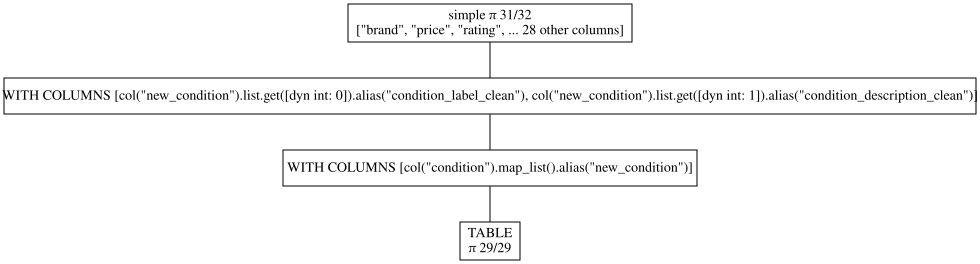

In [23]:
# Transforming the dataframe, creating the `condition_label` and `condition_description` variables
df_lazy_conditions = df.lazy().with_columns(
    pl.col('condition')
    # Applying the `map_condition` function, which maps a string to a predefined label and its corresponding description
    .map_elements(
        function=map_condition,
        skip_nulls=False,
        return_dtype=pl.List(pl.Utf8)
    ).alias('new_condition')  # Creating a temporary column to store results
).with_columns(
    pl.col('new_condition').list.get(0).alias('condition_label_clean'),  # Extract label
    pl.col('new_condition').list.get(1).alias('condition_description_clean')  # Extract description
).drop('new_condition')  # Dropping the temporary column

# Visualize the query plan for the transformation
LazyFrame.show_graph(df_lazy_conditions)

Here we take a look at the values from our `condition` column, and their correspondent **condition labels** and **condition descriptions**.

In [24]:
# Selecting all unique values for condition, and their soon-to-be assigned condition labels and condition descriptions
df_lazy_conditions.unique(
    subset='condition',
    maintain_order=True,
).sort(
    by='condition',
    descending=False,
).select(
    'condition', 'condition_label_clean', 'condition_description_clean'
).collect().to_pandas()

,condition,condition_label_clean,condition_description_clean
0,None,No label,No description
1,Certified - Refurbished: The item is in pristi...,Certified - Refurbished,"The item is in pristine, like-new condition.\n..."
2,Certified - RefurbishedThe item is in pristine...,Certified - Refurbished,"The item is in pristine, like-new condition.\n..."
3,Excellent - Refurbished: The item is in like-n...,Excellent - Refurbished,"The item is in like-new condition, backed by a..."
4,Excellent - RefurbishedThe item is in like-new...,Excellent - Refurbished,"The item is in like-new condition, backed by a..."
5,For parts or not working: An item that does no...,For parts or not working,An item that does not function as intended and...
6,For parts or not workingAn item that does not ...,For parts or not working,An item that does not function as intended and...
7,Good - Refurbished: The item shows moderate we...,Good - Refurbished,The item shows moderate wear and is backed by ...
8,Good - RefurbishedThe item shows moderate wear...,Good - Refurbished,The item shows moderate wear and is backed by ...
9,"New: A brand-new, unused, unopened, undamaged ...",New,"A brand-new, unused, unopened, undamaged item ..."


### **Reformatting `condition`:**

After splitting our `condition` column into `condition_label` and `condition_description`, we will further clean the `condition_label` column by doing the following string operations:
- **Lowercasing:** Modifying all strings to their lowercase equivalent.
- **Standardizing format:** Replacing occurrences hyphens and whitespaces with an underscore (`_`), making the labels more consistent and clean.


In [25]:
# Reformatting `condition_label_clean` and `condition_description_clean`: replacing blank spaces for underscores and lowercasing
df = df_lazy_conditions.with_columns(
    pl.col('condition_label_clean')
    .str.to_lowercase()  # Converting the text to lowercase
    .str.replace_all(' - ', '_')  # Replacing hyphen and spaces between words with underscores
    .str.replace_all(' ', '_')  # Replacing spaces with underscores
    .alias('condition_label_clean')
).collect()  # Materializing the LazyFrame into a DataFrame

# Selecting all unique values for condition, and their respective reformatted condition labels (condition description is not modified, so it is omitted from this lookup)
df.unique(
    subset='condition',
    maintain_order=True,
).sort(
    by='condition',
    descending=False,
).select(
    ['condition', 'condition_label_clean']
)


condition,condition_label_clean
str,str
null,"""no_label"""
"""Certified - Refurbished: The i…","""certified_refurbished"""
"""Certified - RefurbishedThe ite…","""certified_refurbished"""
"""Excellent - Refurbished: The i…","""excellent_refurbished"""
"""Excellent - RefurbishedThe ite…","""excellent_refurbished"""
…,…
"""Seller refurbishedThe item has…","""seller_refurbished"""
"""Used: An item that has been us…","""used"""
"""UsedAn item that has been used…","""used"""


Finally, we take a look at the new `condition_label` variable and its value counts:

In [26]:
# Taking a look at the values counts for the `condition_label_clean` column
df['condition_label_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

condition_label_clean,count,proportion
str,u32,f64
"""used""",2794,0.42
"""new""",1931,0.29
"""no_label""",616,0.09
"""seller_refurbished""",578,0.09
"""for_parts_or_not_working""",173,0.03
"""very_good_refurbished""",151,0.02
"""good_refurbished""",132,0.02
"""excellent_refurbished""",106,0.02
"""open_box""",102,0.02


Observations:
- **New label frequencies**: After cleansing, the most common conditions are `used` (42%) and `new` (29%), which account for the majority of the dataset (71%).
- **Lower cardinality**: We have a considerably minor number of unique values within our `condition_label` variable (**just 10 unique values**), than we did with `condition`, due to the proper cleansing of the data.

## Cleaning `processor`
- **Formatting**: Similarly, as done with other variables, we'll reformat the values, so that `Intel Celeron` is transformed into `intel_celeron`.
- **Unknown values**: There's an abundance of brands with very low frequencies, or unknown values (like `?` or `Does not apply` or `no` or `none`).


In [27]:
# Taking a look at the values counts for the `processor` column
df['processor'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

processor,count,proportion
str,u32,f64
null,2783,0.42
"""Does not apply""",531,0.08
"""Intel Core i5 4th generation""",318,0.05
"""Intel Celeron""",183,0.03
"""Intel Core i5 6th generation""",183,0.03
…,…,…
"""Cable""",1,0.0
"""AMD Ryzen 7 5800HS""",1,0.0
"""Intel Core I7 8650u""",1,0.0


Observations:
- **Missing data**: 42% of the entries are marked as `null` and 8% as `Does not apply`, together representing 50% of the dataset.
- **Low variety**: All processors in the top 10 are of `Intel` brand, with diversity in performance levels but very little in manufacturer.
- **High cardinality**: `processor` contains 462 unique values, as some of its information contains details such as brand (`intel`/`amd`), model (`celeron`), generation (`8th gen`), etc.
- **Feature engineering potential**: Some processors indicate both the model and the generation (`Intel core i5 8th gen`), which can be extracted for further analysis.

### **Reformatting `processor`:**

In this step of our analysis, we're focusing on cleaning up and standardizing the `brand` data to ensure consistency and accuracy. Brands can be listed in many different ways, which can lead to confusion or misinterpretation during analysis. So, we're transforming the brand names into a uniform format that makes it easier to work with.

- **Consistent Formatting:** We ensure all processor names are in lowercase, and we remove any unnecessary spaces or punctuation that could create inconsistencies. (transforming `Intel core - 7th gen.` into `intel_core_7th_gen`).
- **Replacing Uncertain Values:** We also handle special cases where the data might have uncertain or irrelevant values (e.g., `?` or `no`), replacing them with more meaningful values such as `unknown` or `not_applicable`.

In [28]:
 # Define a mapping to handle various non-standard or missing values in the 'processor' column.
processor_replace_map = {
    '?': 'unknown',
    'none': 'unknown',
    'no': 'unknown',
    '^?': 'unknown',
    'does not apply': 'not_applicable'
}

# Apply the replacement logic to the 'processor' column to clean and standardize the values.
df = df.with_columns(
    pl.col('processor')
    .str.to_lowercase()  # Convert text to lowercase for consistency.
    .str.strip_chars()  # Remove any leading or trailing whitespace.
    .str.replace_all(r'\s+|-', '_')  # Replace spaces / hyphens with underscores for consistent naming.
    .str.replace(',', '')  # Removing comas
    .str.strip_chars_end('.')  # Remove any trailing dots.
    .replace(processor_replace_map)  # Apply the replacement map to clean non-standard values.
    .alias('processor_clean')
)

df.select(
    'processor', 'processor_clean'
).head(n=10)

processor,processor_clean
str,str
"""Quad Core""","""quad_core"""
"""Intel Core i7 8th Gen.""","""intel_core_i7_8th_gen"""
"""Intel Core i5-6300U""","""intel_core_i5_6300u"""
"""Intel Celeron N""","""intel_celeron_n"""
"""Intel Core i5 6th Gen.""","""intel_core_i5_6th_gen"""
"""Intel Celeron""","""intel_celeron"""
"""Intel Celeron""","""intel_celeron"""
"""Intel Celeron Dual-Core""","""intel_celeron_dual_core"""
"""i7 7th""","""i7_7th"""


In [29]:
# Taking a look at the poorly formatted `processor` values, with their correspondent values in `processor_clean`
df.select(
    'processor', 'processor_clean',
).filter(
    pl.col('processor').str.to_lowercase().is_in(processor_replace_map)
).unique(
    subset='processor',
    maintain_order=True,
).sort(
    by='processor',
    descending=False,
)

processor,processor_clean
str,str
"""?""","""unknown"""
"""DOES NOT APPLY""","""does_not_apply"""
"""Does Not Apply""","""does_not_apply"""
"""Does not apply""","""does_not_apply"""
"""NONE""","""unknown"""
"""No""","""unknown"""
"""^?""","""unknown"""
"""none""","""unknown"""


Finally, we inspect visually our newly created `processor_clean` variable:

In [30]:
# Taking a look the new `processor_clean` column and its value counts
df['processor_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

processor_clean,count,proportion
str,u32,f64
null,2783,0.42
"""does_not_apply""",538,0.08
"""intel_core_i5_4th_generation""",318,0.05
"""intel_celeron""",183,0.03
"""intel_core_i5_6th_generation""",183,0.03
…,…,…
"""intel_core_i5_10400h""",1,0.0
"""cable""",1,0.0
"""amd_ryzen_7_5800hs""",1,0.0


## Cleaning `screen_size`

In [31]:
# Screen size value counts and their proportion
df['screen_size'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
).to_pandas()

,screen_size,count,proportion
0,None,2730,0.41
1,14 in,703,0.11
2,"14""",603,0.09
3,Does not apply,528,0.08
4,15.6 in,485,0.07
...,...,...,...
154,"13.3"" touchscreen",1,0.00
155,14in,1,0.00
156,2 Meter,1,0.00
157,12 Zoll,1,0.00


### Extracting inches from `screen_size`

In order to have an accurate processing of `screen_size`, we'll extract the inches from the `screen_size` column and assign them to a numerical variable named `screen_size_inches`.

In this way, we can perform further analysis, visualization and numerical computations on the screen size, ensuring that we no longer have to deal with mixed formats.

In [32]:
# Define the regex pattern to extract numeric values (floating point or integer) from screen_size column
screen_size_pattern = r'(\d+(\.\d+)?)'

df = df.with_columns(
    # Clean the screen_size column by extracting the numeric part (screen size in inches)
    pl.col('screen_size')
    .str.extract(screen_size_pattern)  # Extract the numeric part
    .cast(pl.Float32)  # Convert the extracted value to Float64
    .alias('screen_size_inches_clean')
)

df['screen_size_inches_clean'].head(n=10)

screen_size_inches_clean
f32
14.0
14.0
14.0
11.6
12.5
11.6
11.6
11.6
14.0


We can now take a look at the summary statistics for the new `screen_size_inches` variable

In [33]:
# Looking at the summary statistics for the `screen_size_inches` variable
df['screen_size_inches_clean'].describe()

statistic,value
str,f64
"""count""",3331.0
"""null_count""",3289.0
"""mean""",14.397553
"""std""",24.215275
"""min""",2.0
"""25%""",13.0
"""50%""",14.0
"""75%""",15.0
"""max""",1000.0


Observations:
- **Wide Distribution**: The `screen_size_inches_clean` column has a mean value of 14.40 inches, with a standard deviation of 24.22 inches, indicating a relatively wide spread in values. 25% of the data is below 13.0 inches, and 75% is below 15.0 inches.
- **Missing Data**: The column contains a significant amount of missing values (`null_count = 3289`). This highlights the need for potential imputation or cleaning strategies to handle missing data effectively.
- **Extreme Outliers**: The minimum value is 2.0 inches, while the maximum reaches up to 1000.0 inches, suggesting some extreme outliers, which could distort any analysis or model using this data. These outliers should be further investigated and possibly removed or transformed, when doing *statistical analysis*.

### Correcting outliers

We're interested in correcting the outliers in the `screen_size_inches` column, as the maximum value is that of a `1000` inches, which makes very little sense. We'll start by visualizing the top values from that column, to see whether we have several outliers or this is just the product of an error in the data extraction process:

In [34]:
df['screen_size_inches_clean'].filter(
    predicate=df['screen_size_inches_clean'].is_not_null()
).sort(
    descending=True,
)

screen_size_inches_clean
f32
1000.0
1000.0
18.4
18.4
18.4
…
4.5
4.5
2.0


We immediately realize we have just two values of `1000` inches, which are heavily skewing the data. The rest of the distribution lies between the range of `2-18` inches, which is sensible.
In order to address this, we need to find where these values are originally located. Which is, the `screen_size` column:

In [35]:
df.select('screen_size').filter(pl.col('screen_size').str.contains('1000'))

screen_size
str
"""Jumbo Heuer 1000"""
"""Jumbo Heuer 1000"""


We come to the immediate realization that `Jumbo Heuer 1000`, the original `screen_size` value, is clearly not a valid screen size.

 It doesn't contain any numeric value that would correspond to a typical screen size in inches (e.g., "15.6", "12.5", etc.). Instead, the word "1000" is part of a non-numeric string, likely from a misformatted entry during the web scraping process, or the scraping of a wrong tag. As a result, extracting 1000 as the screen size would lead to misleading or incorrect analysis of the data, as screen sizes in inches don't reach values like 1000 inches.

Hence, we replace these unreasonable values with `None` to ensure that the data used for analysis remains consistent and meaningful.

In [36]:
# Replace rows where screen_size_inches_clean is equal to a thousand (which is incorrect data)
df = df.with_columns(
    pl.when(pl.col('screen_size_inches_clean').is_in([1000]))  # Handle extreme values
    .then(None)  # Replace with None (we might also consider using a default value, like the mean or median)
    .otherwise(pl.col('screen_size_inches_clean'))
    .alias('screen_size_inches_clean')
)

# Sorting the screen size in inches in descending order
df['screen_size_inches_clean'].filter(
    predicate=df['screen_size_inches_clean'].is_not_null()
).sort(
    descending=True,
)

screen_size_inches_clean
f32
18.4
18.4
18.4
18.0
18.0
…
4.5
4.5
2.0


Now, we see that the maximum value for the *screen size in inches* variable make a lot more sense. We proceed to visualize its summary statistics once again:

In [37]:
# Looking back at the summary statistics for the `screen_size_inches` variable
df['screen_size_inches_clean'].describe()

statistic,value
str,f64
"""count""",3329.0
"""null_count""",3291.0
"""mean""",13.805422
"""std""",1.612389
"""min""",2.0
"""25%""",13.0
"""50%""",14.0
"""75%""",15.0
"""max""",18.4


Observations:
- **Narrower distribution**: The new statistics show a mean of `13.81` inches with a standard deviation of `1.61` inches. This is an **HIGH REDUCTION** in variability, particularly compared to the previous standard deviation of `24.22` inches. This suggests that removing extreme outliers has led to a more consistent and predictable distribution of screen sizes.

## Cleaning `manufacturer_color` & `color`
Manufacturer color consists of the color specified by the laptop manufacturer. By analyzing the value counts in the `manufacturer_color` column, we can visualize that:
- Manufacturer color is almost composed entirely of `NULL` values, with 97% of its values being null.
- Some entries represent multiple colors in a single field (e.g: `Black & Silver`).
- Most entries have very little frequency, appearing a single time in the entire column. These rare values might be considered noise (and grouped into a rare label category, such as `rare` or `other`) or might to be grouped into broader categories by using the color label (such as grouping `Mica Silver` and `Ice Blue` into a broader `Blue` category).

In [38]:
# Color value counts and their proportion
df['manufacturer_color'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

manufacturer_color,count,proportion
str,u32,f64
null,6435,0.97
"""Black""",46,0.01
"""Silver""",37,0.01
"""Gray""",12,0.0
"""Natural Silver""",7,0.0
…,…,…
"""Space Gray""",1,0.0
"""Platinum Gray""",1,0.0
"""Gray / Black""",1,0.0


Observations:
- **Almost all data is NULL**: The `manufacturer_color` column contains a large amount of missing data, with 6435 instances marked as `null`, representing 97% of the dataset. This makes the variable have very little influence for further analysis or modeling techniques.
- **Diverse color variants**: The column contains various color names with different variations and formats, such as `Black & Silver` and `Matte Black`, as well as entries like `Iron Grey, Ice Blue` and `Scarlet red cover and base, natural silver keyboard frame` which suggest complex multi-color or detailed descriptions. These need to be **STANDARDIZED FOR CONSISTENCY**.
- **Low Frequency Entries**: A significant number of color values appear only once or twice. These rare values might be considered noise or need to be grouped into broader categories to improve the utility of this feature for analysis or modeling.


Similarly, `color` consists of the actual color of the laptop as listed by the seller. By analyzing the value counts in the `color` column, we can visualize that:
- Color is currently a variable with a high number of nulls, which compose approx. 68% of the column.
- Color contains data in spanish, as evidenced by some of its values: `borgoña` (burgundy), `blanco` (white) or `negro` (black).
- Some entries represent multiple colors in a single field (e.g: `Black/ Blue / Sandtone / Platinum`).

In [39]:
# Color value counts and their proportion
df['color'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

color,count,proportion
str,u32,f64
null,4471,0.68
"""Black""",982,0.15
"""Silver""",370,0.06
"""Negro""",264,0.04
"""Gray""",254,0.04
…,…,…
"""Space Gray""",1,0.0
"""Silver and Black""",1,0.0
"""Black / Gray""",1,0.0


Observations:
- **Missing Data**: A significant portion of the data is missing, with 68% of instances marked as `null`. This indicates that a large part of the `color` information is unavailable, which may require additional cleaning, maybe imputation strategies, to handle effectively.
- **Different Languages**: The `color` column includes color names in spanish, such as `Negro` (Spanish for black) and `Gris` (Spanish for gray), as well as English terms like `Carbon Black` and `Silver`. This inconsistency in language could lead to confusion in analysis or models, and standardizing the language or grouping similar colors may be beneficial.
- **Multiple Colors**: Some entries, like `Black/ Blue / Sandtone / Platinum` or `Multicolor`, represent multiple colors in a single field. These values may need to be split into individual colors or categorized into a broader "multicolor" group to maintain consistency and facilitate analysis.

### **Reformatting `manufacturer_color`:**
In this step of our analysis, we're focusing on cleaning up and standardizing the `manufacturer_color` data to ensure consistency and accuracy.
- **Reducing cardinality:** The color data may contain variations or inconsistencies in how colors are labeled (e.g., `multi-color` vs. `multicolor`). We address this by grouping similar colors under consistent labels, reducing the number of unique color categories. We also map color variations (e.g, `sky blue`, `light blue`) to a single color (`blue`).
- **Standardizing format:** Check whether the color listed for each item matches a set of predefined valid colors. Ensures that all color data follows a consistent format.

In [40]:
# List of valid color values for consistency checks
valid_color_values = ['beige', 'black', 'blue', 'bronze', 'brown', 'burgundy', 'gold', 'gray', 'green', 'grey',
                      'orange', 'pink', 'platinum', 'purple', 'red', 'silver', 'teal', 'white', 'yellow']

# Spanish-to-English color translation map
colors_translation = {
    'negro': 'black',
    'borgoña': 'burgundy',
    'platino': 'platinum',
    'gris': 'grey',
    'blanco': 'white',
    'plata transparente': 'transparent silver',
}

# Color replacement map
color_replace_map = {
    'multi': 'multicolor',
    'multi-color': 'multicolor',
    'blk': 'black',
    **colors_translation,
}

color_replace_map

{'multi': 'multicolor',
 'multi-color': 'multicolor',
 'blk': 'black',
 'negro': 'black',
 'borgoña': 'burgundy',
 'platino': 'platinum',
 'gris': 'grey',
 'blanco': 'white',
 'plata transparente': 'transparent silver'}

In [41]:
def clean_color(color: str, color_list: list = valid_color_values) -> str:
    """
    Cleans the input color string by categorizing it based on the presence of valid colors.

    The function checks if the input `color` matches any of the colors in the `color_list`.
    It returns a category based on the number of matches:
    - If the color matches more than one valid color, it returns 'multicolor'.
    - If the color matches exactly one valid color, it returns that color (e.g: 'red').
    - If no valid colors are found, it returns 'other'.

    Args:
        color (str): The input color string to be cleaned and categorized.
        color_list (list, optional): A list of valid colors to check against. Defaults to `valid_color_values`.

    Returns:
        str: The cleaned and categorized color, either a valid color, 'multicolor', or 'other'.
    """
    color_count = sum(1 for c in color_list if c in color.lower())

    if color_count > 1:
        return 'multicolor'
    elif color_count == 1:
        return next((c for c in valid_color_values if c in color.lower()), 'other')
    else:
        return 'other'

In [42]:
# Creates an expression to search for valid colors
valid_color_string_pattern = "|".join(re.escape(color) for color in valid_color_values)

# Prepare the color column by converting to lowercase and applying the color replacements
manufacturer_color_reformatted = (
    pl.col('manufacturer_color')
    .str.to_lowercase()
    .replace(color_replace_map)
)

df = df.with_columns(
    pl.coalesce(
        # If color is valid then apply the `clean_color` function, and map its value to a valid color, multicolor or other (rare label, for invalid color categories)
        pl.when(manufacturer_color_reformatted.str.contains(valid_color_string_pattern))
        .then(manufacturer_color_reformatted.map_elements(clean_color, return_dtype=pl.Utf8)),
        # If color value is set to multicolor, then return multicolor
        pl.when(manufacturer_color_reformatted.eq('multicolor'))
        .then(pl.lit('multicolor'))
        # If value is not multicolor nor a single color,then assign it to `other`
        .otherwise(pl.lit('other'))
    )
    .str.replace('grey',
                 'gray')  # Naturally, we need to map grey to gray (or vice versa) as it represents the same color
    .alias('manufacturer_color_clean')
)

df.select(
    'manufacturer_color', 'manufacturer_color_clean'
).unique(
    subset='manufacturer_color',
    maintain_order=True,
).head(10)

manufacturer_color,manufacturer_color_clean
str,str
null,"""other"""
"""Black""","""black"""
"""Mineral Silver""","""silver"""
"""Pure Silver""","""silver"""
"""Storm Gray""","""gray"""
"""Iron Grey""","""gray"""
"""Performance Blue""","""blue"""
"""black""","""black"""
"""Graphite Gray""","""gray"""


We further inspect the original unique values of the `manufacturer_color` column, and its correspondent mapping in `manufacturer_color_clean`:

In [43]:
# Taking a look at all the transformed color labels
df.select(
    'manufacturer_color', 'manufacturer_color_clean',
).unique(
    subset='manufacturer_color',
    maintain_order=True,
).sort(
    by='manufacturer_color',
).transpose(
    include_header=True,
    header_name='column_name',
)

column_name,column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,column_44,column_45,column_46,column_47,column_48,column_49,column_50
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""manufacturer_color""",null,"""3000""","""5000""","""Abyss Blue""","""Arctic Gray""","""Black""","""Black & Silver""","""Brushed Black""","""Carbon Black""","""Dark Teal""","""Deep Black""","""Graphite Black""","""Graphite Gray""","""Gray""","""Gray / Black""","""Grey""","""Ice Blue/Iron Gray""","""Iron Grey""","""Iron Grey, Ice Blue""","""Jet Black""","""Matte Black""","""Mica Silver""","""Mineral Silver""","""Moonstone Grey""","""Natural Silver""","""Neptune Blue""","""Nightfall Black""","""Peacock Teal""","""Performance Blue""","""Phantom Black""","""Phantom Gray""","""Platinum""","""Platinum Gray""","""Platinum Grey""","""Platinum Silver""","""Poseidon Blue""","""Prism Black""","""Pure Silver""","""Royal Blue""","""Sandstone""","""Scarlet red cover and base, na…","""Silver""","""Silver/Grey""","""Sky""","""Space Gray""","""Steel Gray""","""Storm Gray""","""Titanium Gray""","""Yes""","""black""","""onyx black"""
"""manufacturer_color_clean""","""other""","""other""","""other""","""blue""","""gray""","""black""","""multicolor""","""black""","""black""","""teal""","""black""","""black""","""gray""","""gray""","""multicolor""","""gray""","""multicolor""","""gray""","""multicolor""","""black""","""black""","""silver""","""silver""","""gray""","""silver""","""blue""","""black""","""teal""","""blue""","""black""","""gray""","""platinum""","""multicolor""","""multicolor""","""multicolor""","""blue""","""black""","""silver""","""blue""","""other""","""multicolor""","""silver""","""multicolor""","""other""","""gray""","""gray""","""gray""","""gray""","""other""","""black""","""black"""


### **Reformatting `color`:**
We do similarly with `color` as we did with `manufacturer_color` by translating, reducing cardinality and standardizing its format in the following manner:
- **Translating from Spanish to English:** We translate color names from Spanish to English to ensure that all color information is standardized, regardless of the language it was originally provided in.
- **Reducing cardinality:** The color data may contain variations or inconsistencies in how colors are labeled (e.g., `multi-color` vs. `multicolor`). We address this by grouping similar colors under consistent labels, reducing the number of unique color categories. We also map color variations (e.g, `sky blue`, `light blue`) to a single color (`blue`).
- **Standardizing format:** check whether the color listed for each item matches a set of predefined valid colors. Ensures that all color data follows a consistent format.

In [44]:
# Prepare the color column by converting to lowercase and applying the color replacements
color_reformatted = (
    pl.col('color')
    .str.to_lowercase()
    .replace(color_replace_map)
)

df = df.with_columns(
    pl.coalesce(
        # If color is valid then apply the `clean_color` function, and map its value to a valid color, multicolor or other (rare label, for invalid color categories)
        pl.when(color_reformatted.str.contains(valid_color_string_pattern))
        .then(color_reformatted.map_elements(clean_color, return_dtype=pl.Utf8)),
        # If color value is set to multicolor, then return multicolor
        pl.when(color_reformatted.eq('multicolor'))
        .then(pl.lit('multicolor'))
        # If value is not multicolor nor a single color,then assign it to `other`
        .otherwise(pl.lit('other'))
    )
    .str.replace('grey',
                 'gray')  # Naturally, we need to map grey to gray (or vice versa) as it represents the same color
    .alias('color_clean')
)

df.select(
    'color', 'color_clean'
).head(n=10)

color,color_clean
str,str
"""Gray""","""gray"""
"""Black""","""black"""
"""Black""","""black"""
"""Black""","""black"""
null,"""other"""
"""Black""","""black"""
"""Black""","""black"""
"""Gray, Granite Gray""","""gray"""
"""Black""","""black"""


We further inspect the original unique values of the `color` column, and its correspondent mapping in `color_clean`:

In [45]:
# Taking a look at all the transformed color labels
df.select(
    'color', 'color_clean',
).unique(
    subset='color',
    maintain_order=True,
).sort(
    by='color',
).transpose(
    include_header=True,
    header_name='column_name',
)

column_name,column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,…,column_46,column_47,column_48,column_49,column_50,column_51,column_52,column_53,column_54,column_55,column_56,column_57,column_58,column_59,column_60,column_61,column_62,column_63,column_64,column_65,column_66,column_67,column_68,column_69,column_70,column_71,column_72,column_73,column_74,column_75,column_76,column_77,column_78,column_79,column_80,column_81,column_82
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""color""",null,"""Abyss Blue""","""Arctic Grey""","""BLACK""","""BLK""","""Beige""","""Black""","""Black / Gray""","""Black / Grey""","""Black / Silver""","""Black/ Blue / Sandtone / Plati…","""Black/Blue""","""Black/Gray""","""Black/Red""","""Blanco""","""Blue""","""Bronze""","""Brown""","""Carbon Black""","""Charcoal Gray""","""Cloud Grey""","""Dark Brown""","""Dark Grey""","""Dark Metallic Moon""","""Eclipse Gray""","""Fog Blue Aluminum""","""Gold""","""Gray""","""Gray / Silver""","""Gray and Black""","""Gray, Blue""","""Gray, Granite Gray""","""Gray, Platinum Silver""","""Green""","""Grey""","""Grey/Black""",…,"""Multicolor""","""Natural Silver""","""Negro""","""Orange""","""Pink""","""Plata Transparente""","""Platino""","""Platinum""","""Platinum Silver""","""Pure Silver""","""Purple""","""Quiet Blue""","""Red""","""STEEL GRAY""","""Sandstone""","""See Photos""","""Silver""","""Silver & Black""","""Silver + Black""","""Silver / Black""","""Silver and Black""","""Silver, Black""","""Silver, Metallic Silver""","""Silver, Platinum Silver""","""Silver/Black""","""Space Gray""","""Standard""","""Steam Blue""","""Storm Gray""","""Teal""","""Tech Black""","""Warm Gold""","""White""","""Yellow""","""black""","""borgoña""","""see pictures"""
"""color_clean""","""other""","""blue""","""gray""","""black""","""black""","""beige""","""black""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""white""","""blue""","""bronze""","""brown""","""black""","""gray""","""gray""","""brown""","""gray""","""other""","""gray""","""blue""","""gold""","""gray""","""multicolor""","""multicolor""","""multicolor""","""gray""","""multicolor""","""green""","""gray""","""multicolor""",…,"""multicolor""","""silver""","""black""","""orange""","""pink""","""silver""","""platinum""","""platinum""","""multicolor""","""silver""","""purple""","""blue""","""red""","""gray""","""other""","""other""","""silver""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""multicolor""","""silver""","""multicolor""","""multicolor""","""gray""","""other""","""blue""","""gray""","""teal""","""black""","""gold""","""white""","""yellow""","""black""","""burgundy""","""other"""


We can also visualize its new value counts:

In [46]:
# Color cleaned value counts and their proportion
df['color_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

color_clean,count,proportion
str,u32,f64
"""other""",4488,0.68
"""black""",1263,0.19
"""silver""",381,0.06
"""gray""",296,0.04
"""blue""",62,0.01
…,…,…
"""gold""",3,0.0
"""orange""",2,0.0
"""bronze""",2,0.0


Observations:
- **Lower cardinality and higher frequencies**: As a consequence of mapping colors into broader color categories and the rare category (`other`) the cardinality has decreased from more than 80 different colors to 20. This has also caused the increase in the proportion of several categories, such as `black` increasing from 15% to 19%.

## Cleaning `type`

In [47]:
df['type'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

type,count,proportion
str,u32,f64
null,3331,0.5
"""Notebook/Laptop""",2520,0.38
"""Ordinateur portable/Pc portabl…",221,0.03
"""Laptop""",144,0.02
"""Chromebook""",65,0.01
…,…,…
"""AWESOME""",1,0.0
"""Laptop/Portable Workstation""",1,0.0
"""Rugged Tablet PC""",1,0.0


In [48]:
def map_type(type_str: str) -> str:
    if type_str is None or type_str == "":  # Check for None or NaN (float type)
        return 'unknown'

    str_casefold = type_str.casefold()
    if (
            'netbook' in str_casefold or 'notebook' in str_casefold or 'laptop' in str_casefold or 'macbook' in str_casefold or 'thinkpad' in str_casefold
            or 'chromebook' in str_casefold or 'ultrabook' in str_casefold):
        return 'laptop'
    if 'pc' in str_casefold or 'computer' in str_casefold:
        return 'pc'
    if 'tablet' in str_casefold:
        return 'tablet'
    return 'other'

In [49]:
df = df.with_columns(
    pl.col('type')
    .map_elements(map_type, skip_nulls=False, return_dtype=pl.Utf8)  # Map the function to the 'Type' column
    .alias('type_clean')  # Create the new column
)

In [50]:
df['type_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

type_clean,count,proportion
str,u32,f64
"""unknown""",3331,0.5
"""laptop""",2919,0.44
"""pc""",263,0.04
"""other""",88,0.01
"""tablet""",19,0.0


## Cleaning `model`

In [51]:
df = df.with_columns(
    pl.col('model')
    .str.to_lowercase()  # Convert the string to lowercase
    .str.replace_all(r'\s+', '_')  # Replace spaces with underscores
    .str.replace_all(r'[^a-z0-9_]', '')  # Remove non-alphanumeric characters (except underscores)
    .alias('model_clean')  # Create a new column with the cleaned model names
)

df.select(
    'model', 'model_clean'
).head(n=10)

model,model_clean
str,str
"""CoreBook X""","""corebook_x"""
"""Dell Latitude 7490""","""dell_latitude_7490"""
"""Dell Latitude E5470""","""dell_latitude_e5470"""
"""HP Chromebook 11 G6""","""hp_chromebook_11_g6"""
"""Various Models""","""various_models"""
"""Chromebook C738T-C44Z""","""chromebook_c738tc44z"""
"""HP Chromebook 11 G5""","""hp_chromebook_11_g5"""
"""Chromebook C720-2848""","""chromebook_c7202848"""
"""Dell Latitude 7480""","""dell_latitude_7480"""


## Cleaning `os`

In [52]:
# Operating system value counts and their proportion.
df['os'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

os,count,proportion
str,u32,f64
null,3580,0.54
"""Windows 11 Pro""",626,0.09
"""Windows 10 Pro""",441,0.07
"""Windows 10 Pros""",368,0.06
"""Chrome OS""",334,0.05
…,…,…
"""Windows 10 pers""",1,0.0
"""Windows XP Professional Sp3""",1,0.0
"""Windows 7 Professional, Window…",1,0.0


In [53]:
# Define a function that maps the OS types based on the text
def map_os_type(os: str) -> str:
    if os is None or isinstance(os, float) or os == "":  # Check for None or NaN (float type)
        return 'unknown'

    str_casefold = os.casefold()

    # Check for various OS types
    if 'linux' in str_casefold or 'kali' in str_casefold or 'ubuntu' in str_casefold:
        return 'linux'
    elif 'window' in str_casefold or 'windows' in str_casefold or 'win' in str_casefold:
        return 'windows'
    elif 'chrome' in str_casefold:
        return 'chrome'
    elif 'android' in str_casefold:
        return 'android'
    elif 'mac' in str_casefold or 'macos' in str_casefold:
        return 'mac'
    else:
        return 'other'

In [54]:
df = df.with_columns(
    pl.col("os")  # Select the OS column
    .map_elements(map_os_type, skip_nulls=False, return_dtype=pl.Utf8)  # Apply the function using map_elements
    .alias("os_clean")  # Create a new column with the mapped values
)

# Operating system cleaned value counts and their proportion.
df['os_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

os_clean,count,proportion
str,u32,f64
"""unknown""",3580,0.54
"""windows""",2522,0.38
"""chrome""",336,0.05
"""other""",137,0.02
"""linux""",23,0.0
"""mac""",13,0.0
"""android""",9,0.0


## Cleaning `country_region_of_manufacturer`

This variable represents country where the laptop was manufactured. As it is a string variable, it needs to be standardized and reformatted as required.

We'll start by taking a look at its value counts:

In [55]:
# Country region of manufacturer value counts and their proportion.
df['country_region_of_manufacturer'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

country_region_of_manufacturer,count,proportion
str,u32,f64
null,6417,0.97
"""China""",101,0.02
"""United States""",57,0.01
"""Taiwan""",13,0.0
"""Unknown""",12,0.0
"""Japan""",10,0.0
"""Ireland""",7,0.0
"""Australia""",3,0.0


Observations:
- **Missing Data**: The `country_region_of_manufacturer` feature has a large proportion of missing values, with 6417 entries marked as `null`, representing 97% of the dataset. This significant amount of missing data should be addressed through imputation or exclusion strategies.
- **Concentration in Few Regions**: The majority of the values are concentrated in a small set of countries, with China being the most common, followed by the United States and Taiwan. This indicates that the data might be heavily skewed towards certain manufacturers. Other countries such as Japan, Ireland, and Australia have very few entries (less than 1% of the data), which suggests that these values are underrepresented and can be grouped into broader categories for analysis or modeling.


### Reformatting `country_region_of_manufacturer`
We now proceed to reformat the `country_region_of_manufacturer` variable, by doing string operations (such as lowercasing, replacing all whitespaces with underscores) and assigning all `null` values to the `unknown` category.

In [56]:
df = df.with_columns(
    pl.col('country_region_of_manufacturer')
    .str.to_lowercase()  # Convert all text to lowercase
    .str.replace_all(r'\s+', '_')  # Replace all whitespaces with underscores
    .fill_null('unknown')  # Replace null values with 'unknown'
    .alias('country_of_manufacturer_clean')  # Save as a new column
)

df.select(
    'country_region_of_manufacturer', 'country_of_manufacturer_clean'
).unique(
    subset='country_region_of_manufacturer'
)

country_region_of_manufacturer,country_of_manufacturer_clean
str,str
"""Japan""","""japan"""
null,"""unknown"""
"""Ireland""","""ireland"""
"""Unknown""","""unknown"""
"""China""","""china"""
"""Australia""","""australia"""
"""United States""","""united_states"""
"""Taiwan""","""taiwan"""


In [57]:
# Country of manufacturer cleaned value counts and their proportion.
df['country_of_manufacturer_clean'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

country_of_manufacturer_clean,count,proportion
str,u32,f64
"""unknown""",6429,0.97
"""china""",101,0.02
"""united_states""",57,0.01
"""taiwan""",13,0.0
"""japan""",10,0.0
"""ireland""",7,0.0
"""australia""",3,0.0


## Cleaning `storage_type`

In [58]:
df['storage_type'].value_counts(
    sort=True,
    parallel=True,
).with_columns(
    (pl.col('count') / df.height).round(2).alias('proportion')
)

storage_type,count,proportion
str,u32,f64
null,4232,0.64
"""SSD (Solid State Drive)""",1542,0.23
"""SSD""",306,0.05
"""HDD (Hard Disk Drive)""",215,0.03
"""eMMC""",210,0.03
…,…,…
"""SSD + HDD""",1,0.0
"""N.A.""",1,0.0
"""Not included""",1,0.0


Observations:
- **Missing Data**: The `storage_type` column contains a significant number of missing values (`null_count = 4232`), representing 64% of the data.
- **Multiple Formats**: The data includes various representations for similar storage types (e.g., "SSD", "SSD (Solid State Drive)", "Solid State Drive"), which could lead to inconsistencies. These variations need to be standardized and grouped for better analysis and modeling.
- **Uncommon and Irrelevant Entries**: There are a few outlier values such as "Touchscreen", "256GBSSD", and "SSD or SSD", which seem irrelevant to the `storage_type` category. These should be reviewed and cleaned accordingly to ensure data quality.

In [59]:
def map_storage_type(string: str) -> str:
    if string is None or string == "":
        return 'unknown'  # Handle None or empty strings before processing

    # String suitable for caseless comparisons
    str_casefold = string.casefold()

    # Check if both 'ssd' and 'hdd' are present
    if 'ssd' in str_casefold and 'hdd' in str_casefold:
        return 'hdd_or_ssd'
    # Check for 'ssd'
    elif 'ssd' in str_casefold:
        return 'ssd'
    # Check for 'hdd'
    elif 'hdd' in str_casefold:
        return 'hdd'
    # Check for 'emmc'
    elif 'emmc' in str_casefold:
        return 'emmc'
    else:
        return 'other'

In [60]:
df = df.with_columns(
    pl.col("storage_type")  # Select the storage_type column
    .map_elements(map_storage_type, skip_nulls=False, return_dtype=pl.Utf8)  # Apply the function using map_elements
    .alias("storage_type_clean")  # Create a new column with the mapped values
)

df['storage_type_clean'].value_counts(
    sort=True,
    parallel=True,
)

storage_type_clean,count
str,u32
"""unknown""",4232
"""ssd""",1860
"""hdd""",218
"""emmc""",210
"""other""",66
"""hdd_or_ssd""",34
